# 01 — Limpieza y auditoría de calidad

**TP Integrador · 82.04 Analítica Descriptiva (ITBA) · Grupo 2 · 2da pre-entrega**

Este notebook responde al primer punto de la consigna: **transformar el dataset crudo
en una matriz confiable**. No ejecuta la limpieza —eso lo hace `limpieza.py`, que es
reproducible desde la línea de comandos— sino que **audita y justifica** cada decisión
que ese script toma.

| Sección | Qué pide la consigna | Qué se hace acá |
|---|---|---|
| 1 | Radiografía del crudo | Tipos, memoria, duplicados, fecha de corte, cobertura, cardinalidad y coherencia entre variables |
| 2 | Tratamiento estratégico de nulos | Se clasifican por naturaleza y se **compara empíricamente** excluir / imputar con media / imputar por grupo / modelo predictivo |
| 3 | Detección de outliers | Cuatro criterios matemáticos comparados + detección contextual |
| 4 | Normalización monetaria | La trampa de `precio_m2` y cómo se resuelve |
| 5 | Trazabilidad | Cada fila excluida, con su motivo |

**Reproducir:** `py src/limpieza.py --tc 1500`


In [1]:
import os, sys, warnings
from pathlib import Path

# El kernel puede arrancar en la raiz del repo o en Entrega 2 (depende del
# editor). Se busca la carpeta notebooks/ para que ../src y ../data resuelvan
# siempre igual, sin importar desde donde se abra el notebook.
def _carpeta_notebooks() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents]:
        for cand in (base, base / "Entrega 2"):
            if (cand / "src" / "eda.py").exists():
                return cand / "notebooks"
    raise FileNotFoundError("No se encontro Entrega 2/src: abrir el notebook dentro del repo")

os.chdir(_carpeta_notebooks())
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import eda
import supuestos as S

eda.estilo()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 190)
warnings.filterwarnings("ignore", category=FutureWarning)

CRUDO   = "../data/raw/dataset_maestro.csv"
LIMPIO  = "../data/processed/dataset_limpio.csv"
EXCL    = "../data/processed/dataset_excluidos.csv"
AUDIT   = "../data/processed/auditoria_calidad.csv"

crudo     = pd.read_csv(CRUDO,  encoding="utf-8-sig", low_memory=False)
limpio    = pd.read_csv(LIMPIO, encoding="utf-8-sig", low_memory=False)
excluidos = pd.read_csv(EXCL,   encoding="utf-8-sig", low_memory=False)
auditoria = pd.read_csv(AUDIT,  encoding="utf-8-sig")

print(f"crudo     {crudo.shape[0]:>7,} filas x {crudo.shape[1]:>3} columnas")
print(f"limpio    {limpio.shape[0]:>7,} filas x {limpio.shape[1]:>3} columnas")
print(f"excluidos {excluidos.shape[0]:>7,} filas")
print(f"retencion {len(limpio)/len(crudo)*100:.1f}%")

crudo      14,867 filas x  55 columnas
limpio     12,097 filas x  66 columnas
excluidos   2,770 filas
retencion 81.4%


## 1. Radiografía del dataset crudo

Antes de decidir qué hacer con los datos hay que saber qué hay. Tres preguntas:
¿de qué tipo es cada columna, cuánto pesa, y hay filas repetidas?

In [2]:
tipos = (crudo.dtypes.astype(str).value_counts()
         .rename_axis("dtype").to_frame("columnas"))
tipos["memoria_MB"] = [crudo.select_dtypes(include=[t]).memory_usage(deep=True).sum() / 1e6
                       if t != "object" else
                       crudo.select_dtypes(include=["object"]).memory_usage(deep=True).sum() / 1e6
                       for t in tipos.index]
print(f"Memoria total del crudo: {crudo.memory_usage(deep=True).sum()/1e6:,.1f} MB")
print(f"El 90% lo ocupan tres columnas de texto libre: titulo, descripcion, detalles")
tipos.round(1)

Memoria total del crudo: 36.6 MB
El 90% lo ocupan tres columnas de texto libre: titulo, descripcion, detalles


,columnas,memoria_MB
dtype,,
int64,26,3.1
str,17,32.1
float64,12,1.4


In [3]:
# Duplicacion: mismo aviso publicado dos veces, y mismo INMUEBLE publicado
# bajo dos avisos distintos. El segundo caso es el que importa y no lo
# detecta un drop_duplicates() sobre el id.
dup_id  = crudo["id_aviso"].duplicated().sum()
dup_url = crudo["url"].duplicated().sum()
clave_inmueble = ["operacion", "barrio", "calle", "sup_total_m2", "precio_valor", "ambientes"]
dup_inm = crudo.duplicated(subset=clave_inmueble, keep="first").sum()

print(f"avisos con id repetido        : {dup_id:>5}")
print(f"avisos con url repetida       : {dup_url:>5}")
print(f"mismo inmueble, distinto aviso: {dup_inm:>5}   <- este es el que hay que resolver")
print()
print(f"Clave usada para el segundo caso: {' + '.join(clave_inmueble)}")

avisos con id repetido        :     0
avisos con url repetida       :     0
mismo inmueble, distinto aviso:   341   <- este es el que hay que resolver

Clave usada para el segundo caso: operacion + barrio + calle + sup_total_m2 + precio_valor + ambientes


**Lectura.** No hay un solo `id_aviso` repetido: el scraper ya deduplica por identificador.
Lo que sí aparece son avisos distintos que describen el mismo inmueble —la misma unidad
publicada por dos agentes de la red—. Se detectan por la combinación de operación, barrio,
calle, superficie, precio y ambientes: seis coincidencias exactas no son casualidad.

Conservarlos inflaría artificialmente los barrios donde más agentes compiten, que son
justamente los de mayor volumen. Sería un sesgo silencioso.

### 1.1 Fecha de corte y cobertura

¿A qué momento y a qué territorio corresponde el dataset? Las dos cosas acotan qué se
puede concluir: un corte único no permite hablar de tendencias, y una cobertura
incompleta no permite comparar barrios.

In [4]:
# Fecha de corte: fecha_scraping viene en UTC; se pasa a hora de Buenos Aires.
fechas = pd.to_datetime(crudo["fecha_scraping"], utc=True).dt.tz_convert("America/Argentina/Buenos_Aires")
print(f"Primer aviso extraido : {fechas.min():%Y-%m-%d %H:%M} (hora argentina)")
print(f"Ultimo aviso extraido : {fechas.max():%Y-%m-%d %H:%M}")
print(f"Duracion de la corrida: {(fechas.max() - fechas.min()).total_seconds() / 3600:.1f} horas")
print()

# Cobertura geografica: barrios y comunas oficiales, y coordenadas dentro de CABA.
# Caja aproximada de la Ciudad: latitud -34.71 a -34.52, longitud -58.54 a -58.33.
con_coord = crudo["latitud"].notna() & crudo["longitud"].notna()
fuera_caba = con_coord & ~(crudo["latitud"].between(-34.71, -34.52)
                           & crudo["longitud"].between(-58.54, -58.33))
print(f"Barrios presentes     : {crudo['barrio'].nunique()} de 48")
print(f"Comunas presentes     : {crudo['comuna'].nunique()} de 15")
print(f"Avisos con coordenadas: {con_coord.mean() * 100:.1f}%")
print(f"Coordenadas fuera de CABA: {fuera_caba.sum()}")
print()
print("Avisos por barrio (los 5 con menos):")
print(crudo["barrio"].value_counts().tail(5).to_string())

Primer aviso extraido : 2026-08-16 18:20 (hora argentina)
Ultimo aviso extraido : 2026-08-16 23:42
Duracion de la corrida: 5.4 horas

Barrios presentes     : 48 de 48
Comunas presentes     : 15 de 15
Avisos con coordenadas: 99.9%
Coordenadas fuera de CABA: 1

Avisos por barrio (los 5 con menos):
barrio
versalles          55
villa real         35
villa soldati      32
agronomia          30
villa riachuelo    27


**Lectura.** La extracción completa corre en una sola noche: es un **corte transversal**,
no una serie. Por eso ningún resultado del trabajo se lee como tendencia, y el contexto
temporal se toma de fuentes externas (gráfico 14 del notebook 03). La cobertura
geográfica es completa en barrios y comunas, pero desigual en volumen: los barrios con
pocos avisos no sostienen una mediana propia, y por eso el análisis exige mínimos de
cobertura (`MIN_VENTAS_BARRIO` en `supuestos.py`).

### 1.2 Cardinalidad

La cantidad de valores distintos de cada columna dice qué tipo de variable es en la
práctica, más allá de su `dtype`: identificador, categórica, binaria o continua.

In [5]:
card = crudo.nunique().to_frame("valores_unicos")
card["pct_filas"] = (card.valores_unicos / len(crudo) * 100).round(1)
card["lectura"] = pd.cut(card.valores_unicos, [-1, 1, 2, 60, 2_000, len(crudo) - 1, len(crudo)],
                         labels=["constante", "binaria", "categorica", "discreta amplia",
                                 "continua o texto", "identificador"])
print(card.lectura.value_counts().sort_index().to_string())
print()
card[card.lectura.isin(["constante", "identificador"]) | (card.index.isin(["barrio", "barrio_raw", "tipo_propiedad"]))]

lectura
constante            2
binaria             26
categorica           8
discreta amplia      7
continua o texto    10
identificador        2



,valores_unicos,pct_filas,lectura
portal,1,0.0,constante
id_aviso,14867,100.0,identificador
url,14867,100.0,identificador
tipo_propiedad,23,0.2,categorica
barrio,48,0.3,categorica
barrio_raw,76,0.5,discreta amplia
localidad,1,0.0,constante


**Lectura.** `id_aviso` y `url` tienen un valor por fila: son las **claves** del aviso.
`portal` y `localidad` son constantes (una sola fuente, una sola ciudad) y no aportan
información. `barrio_raw` tiene más valores que los 48 barrios oficiales porque trae los
alias del portal (por ejemplo "Palermo Hollywood"), que el scraper ya normalizó en
`barrio`. `tipo_propiedad` tiene 23 categorías, muchas fuera del alcance residencial: las
filtra `limpieza.py` y quedan registradas en la sección 5.

### 1.3 Coherencia entre variables relacionadas

Un valor puede ser válido por sí solo y absurdo junto a otro. Se controlan los pares
que deben respetar una relación lógica, en el crudo y en el limpio.

In [6]:
def controles_coherencia(df):
    return pd.Series({
        "sup_cubierta > sup_total":         (df.sup_cubierta_m2 > df.sup_total_m2).sum(),
        "dormitorios >= ambientes (2+ amb)": ((df.dormitorios >= df.ambientes) & (df.ambientes >= 2)).sum(),
        "monoambiente con 1 dormitorio":    ((df.ambientes == 1) & (df.dormitorios == 1)).sum(),
        "banos > ambientes":                (df.banos > df.ambientes).sum(),
        "antiguedad negativa":              (df.antiguedad_anios < 0).sum(),
        "precio <= 0":                      (df.precio_valor <= 0).sum(),
    })

pd.DataFrame({"crudo": controles_coherencia(crudo), "limpio": controles_coherencia(limpio)})

,crudo,limpio
sup_cubierta > sup_total,0,0
dormitorios >= ambientes (2+ amb),192,172
monoambiente con 1 dormitorio,728,692
banos > ambientes,28,18
antiguedad negativa,149,0
precio <= 0,0,0


**Lectura.** Las superficies y los precios son coherentes. La **antigüedad negativa** (de −1 a
−3 años, probablemente unidades en pozo mal cargadas) desaparece en el limpio porque `limpieza.py` la trata como
error de carga. Quedan dos incoherencias que se conservan a propósito:

- **Monoambiente con 1 dormitorio.** Es una convención del portal: el único ambiente
  también es el dormitorio. No es un error y no se corrige.
- **Dormitorios iguales a ambientes en unidades de 2 o más.** Un departamento de 3
  ambientes tiene normalmente 2 dormitorios y un living. Son pocos casos, y cuál de las
  dos columnas está mal no se puede saber sin ver la ficha. Se registra como
  **observación pendiente**: `dormitorios` es predictora del modelo de alquiler, y su
  revisión entra con la del modelo en la 3ra entrega.
- **Más baños que ambientes** (18 filas en el limpio). Es posible en casas con toilette
  y baño en suite, pero raro. Por su volumen no mueve ningún resultado, y se deja
  documentado en lugar de corregirlo a ciegas.


## 2. Tratamiento estratégico de los nulos

La consigna plantea la pregunta como una disyuntiva: *¿excluir, imputar con la media, o
usar un modelo predictivo?* La respuesta correcta no es una de las tres para todo el
dataset, sino **una decisión por columna**, y depende de qué significa el nulo.

### 2.1 Un nulo no siempre es un dato faltante

`limpieza.py` clasifica cada columna en tres naturalezas antes de tocar nada.

In [7]:
con_nulos = auditoria[auditoria.n_nulos > 0].copy()
print(f"Columnas con al menos un nulo: {len(con_nulos)} de {len(auditoria)}")
print()
for nat in ["estructural", "informativo", "faltante"]:
    sub = con_nulos[con_nulos.naturaleza == nat]
    print(f"--- {nat.upper()} ({len(sub)} columnas) ---")
    for _, r in sub.iterrows():
        print(f"    {r.columna:<26}{r.pct_nulos:>6.2f}%   {r.decision}")
    print()

Columnas con al menos un nulo: 17 de 60

--- ESTRUCTURAL (5 columnas) ---
    expensas_sobre_alquiler    88.89%   solo definida para alquileres
    alquiler_usd_mes           88.86%   vacia en ventas por definicion
    alquiler_m2_usd_mes        88.86%   vacia en ventas por definicion
    venta_usd                  11.14%   vacia en alquileres por definicion
    venta_m2_usd               11.14%   vacia en alquileres por definicion

--- INFORMATIVO (1 columnas) ---
    detalles                   17.96%   aviso menos detallado -> dummy tiene_detalles

--- FALTANTE (11 columnas) ---
    expensas_usd                2.65%   imputada por mediana de expensas/m2 del barrio x tipo
    expensas_valor              2.65%   se imputa su version en USD, no el valor en moneda original
    es_a_estrenar               1.08%   se conserva el nulo (no interviene en los KPIs)
    antiguedad_rango            1.08%   se conserva el nulo (no interviene en los KPIs)
    antiguedad_anios            1.08%   im

**Por qué la distinción no es semántica sino operativa.**

`alquiler_usd_mes` está vacía en el 88,9% de las filas. Ese número, leído sin contexto,
sugiere una columna inservible. Pero el dataset tiene 10.749 propiedades en venta y 1.348
en alquiler: la columna está completa en el 100% de las filas donde la pregunta tiene
sentido. Imputarla sería inventar el precio de alquiler de departamentos que nadie alquila.

Lo mismo al revés: `detalles` falta en el 18% de los avisos, y ahí la ausencia **es** un dato.
Un aviso sin sección de detalles es un aviso peor cargado. Se convierte en la dummy
`tiene_detalles` en vez de rellenarse.

Solo quedan cuatro columnas donde el dato existe en la realidad y el portal no lo publicó.
Esas son las que se imputan — y la pregunta es con qué.

### 2.2 Comparación empírica de estrategias de imputación

En vez de elegir por costumbre, se mide. El procedimiento es un hold-out honesto:

1. Se toman **solo las filas con el valor observado** (la marca `<col>_imputada == 0`).
2. Se esconde el 20% al azar.
3. Cada estrategia predice esos valores escondidos.
4. Gana la que menos se equivoca, medida en **MAE** (error absoluto mediano y medio).

Las cuatro estrategias que compara la consigna, más una quinta de control.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder

def comparar_imputacion(df, objetivo, grupos_simple, grupos_fino, predictoras):
    """Compara estrategias de imputacion sobre los valores REALMENTE observados."""
    obs = df[df[f"{objetivo}_imputada"] == 0].dropna(subset=[objetivo]).copy()
    tr, te = train_test_split(obs, test_size=0.2, random_state=42)
    y = te[objetivo].values
    res = {}

    # 1. Excluir: no es una imputacion, es el costo de no tenerla.
    res["excluir (se pierden las filas)"] = np.nan

    # 2. Media global — la opcion por defecto de la consigna.
    res["media global"] = np.abs(y - tr[objetivo].mean())

    # 3. Mediana global — misma idea, estimador robusto.
    res["mediana global"] = np.abs(y - tr[objetivo].median())

    # 4. Mediana por grupo grueso y fino.
    for etiqueta, claves in [(f"mediana por {'+'.join(grupos_simple)}", grupos_simple),
                             (f"mediana por {'+'.join(grupos_fino)}", grupos_fino)]:
        med = tr.groupby(claves, observed=True)[objetivo].median()
        pred = te.set_index(claves).index.map(med)
        pred = pd.Series(pred, index=te.index).fillna(tr[objetivo].median())
        res[etiqueta] = np.abs(y - pred.values)

    # 5. Modelo predictivo: arbol con boosting sobre las variables disponibles.
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    # pandas 3 usa un dtype de string propio: preguntar por `== object` ya no
    # alcanza para separar categoricas de numericas.
    num = [c for c in predictoras if pd.api.types.is_numeric_dtype(df[c])]
    cat = [c for c in predictoras if c not in num]
    Xtr = np.hstack([tr[num].astype(float).values, enc.fit_transform(tr[cat].astype(str))])
    Xte = np.hstack([te[num].astype(float).values, enc.transform(te[cat].astype(str))])
    mod = HistGradientBoostingRegressor(max_iter=200, random_state=42).fit(Xtr, tr[objetivo])
    res["modelo predictivo (boosting)"] = np.abs(y - mod.predict(Xte))

    filas = []
    for k, err in res.items():
        if isinstance(err, float) and np.isnan(err):
            filas.append({"estrategia": k, "MAE medio": np.nan, "MAE mediano": np.nan,
                          "% error < 20%": np.nan})
        else:
            # El error relativo no existe donde el valor real es cero
            # (antiguedad "a estrenar", expensas de una casa): se calcula
            # solo sobre los positivos.
            pos = y > 0
            filas.append({"estrategia": k,
                          "MAE medio": err.mean(),
                          "MAE mediano": np.median(err),
                          "% error < 20%": (err[pos] / y[pos] < 0.20).mean() * 100})
    return pd.DataFrame(filas).set_index("estrategia").round(2), len(obs), len(te)

In [9]:
tabla_ant, n_obs, n_te = comparar_imputacion(
    limpio, "antiguedad_anios",
    grupos_simple=["barrio"],
    grupos_fino=["barrio", "tipo_familia"],
    predictoras=["sup_total_m2", "ambientes", "banos", "dormitorios",
                 "barrio", "tipo_familia"])

print(f"ANTIGUEDAD — {n_obs:,} valores observados, {n_te:,} escondidos para evaluar")
print(f"unidad del error: años")
tabla_ant

ANTIGUEDAD — 11,966 valores observados, 2,394 escondidos para evaluar
unidad del error: años


,MAE medio,MAE mediano,% error < 20%
estrategia,,,
excluir (se pierden las filas),NaN,NaN,NaN
media global,21.98,21.49,13.99
mediana global,21.72,20.00,21.65
mediana por barrio,19.68,16.00,27.35
mediana por barrio+tipo_familia,19.10,16.00,26.66
modelo predictivo (boosting),15.47,12.69,31.91


In [10]:
tabla_exp, n_obs_e, n_te_e = comparar_imputacion(
    limpio, "expensas_usd",
    grupos_simple=["barrio"],
    grupos_fino=["barrio", "tipo_familia", "superficie_rango"],
    predictoras=["sup_total_m2", "ambientes", "banos", "dormitorios",
                 "antiguedad_anios", "barrio", "tipo_familia"])

print(f"EXPENSAS — {n_obs_e:,} valores observados, {n_te_e:,} escondidos para evaluar")
print(f"unidad del error: USD por mes")
tabla_exp

EXPENSAS — 11,776 valores observados, 2,356 escondidos para evaluar
unidad del error: USD por mes


,MAE medio,MAE mediano,% error < 20%
estrategia,,,
excluir (se pierden las filas),NaN,NaN,NaN
media global,85.03,73.12,26.47
mediana global,82.67,78.55,22.34
mediana por barrio,75.76,59.37,20.36
mediana por barrio+tipo_familia+superficie_rango,61.40,40.00,31.12
modelo predictivo (boosting),52.85,32.03,34.15


### 2.3 La decisión, y su costo

La tabla ordena las estrategias, pero no decide sola: hay que ver **cuánto cambia el
dataset** según cuál se elija. Una estrategia que gana por mucho sobre una variable que
falta en el 1% de las filas puede no cambiar ninguna conclusión posterior.

In [11]:
for nombre, tabla, col, unidad in [("antiguedad", tabla_ant, "antiguedad_anios", "años"),
                                   ("expensas", tabla_exp, "expensas_usd", "USD/mes")]:
    t = tabla.dropna()
    mejor = t["MAE mediano"].idxmin()
    media = t.loc["media global", "MAE mediano"]
    print(f"--- {nombre.upper()} ---")
    print(f"  mejor estrategia    : {mejor}")
    print(f"  su error mediano    : {t.loc[mejor, 'MAE mediano']:.2f} {unidad}")
    print(f"  imputando con media : {media:.2f} {unidad}")
    print(f"  la media global es un {media/t.loc[mejor,'MAE mediano']-1:+.0%} peor")
    n_imp = int(limpio[f"{col}_imputada"].sum())
    print(f"  filas que se imputan: {n_imp:,} ({n_imp/len(limpio)*100:.2f}% del dataset)")
    print(f"  costo de excluirlas : {n_imp:,} filas menos para el analisis")
    print()

--- ANTIGUEDAD ---
  mejor estrategia    : modelo predictivo (boosting)
  su error mediano    : 12.69 años
  imputando con media : 21.49 años
  la media global es un +69% peor
  filas que se imputan: 131 (1.08% del dataset)
  costo de excluirlas : 131 filas menos para el analisis

--- EXPENSAS ---
  mejor estrategia    : modelo predictivo (boosting)
  su error mediano    : 32.03 USD/mes
  imputando con media : 73.12 USD/mes
  la media global es un +128% peor
  filas que se imputan: 321 (2.65% del dataset)
  costo de excluirlas : 321 filas menos para el analisis



**El modelo predictivo gana en antigüedad, y no por poco.** La tabla lo dice sin
ambigüedad. La pregunta es si esa ventaja cambia algo aguas abajo, y eso depende de sobre
cuántas filas se aplica. El bloque siguiente lo mide en vez de suponerlo.

In [12]:
# Efecto de la eleccion sobre los estadisticos que despues usa el analisis.
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder

def impacto_dataset(df, objetivo, predictoras):
    """Compara el dataset resultante bajo la estrategia adoptada y bajo el modelo."""
    obs = df[df[f"{objetivo}_imputada"] == 0].dropna(subset=[objetivo])
    falt = df[df[f"{objetivo}_imputada"] == 1]
    if len(falt) == 0:
        return None

    num = [c for c in predictoras if pd.api.types.is_numeric_dtype(df[c])]
    cat = [c for c in predictoras if c not in num]
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    Xo = np.hstack([obs[num].astype(float).fillna(-1).values,
                    enc.fit_transform(obs[cat].astype(str))])
    Xf = np.hstack([falt[num].astype(float).fillna(-1).values,
                    enc.transform(falt[cat].astype(str))])
    mod = HistGradientBoostingRegressor(max_iter=200, random_state=42).fit(Xo, obs[objetivo])

    adoptada = pd.concat([obs[objetivo], falt[objetivo]])
    alterna = pd.concat([obs[objetivo], pd.Series(mod.predict(Xf), index=falt.index)])
    return pd.DataFrame({
        "solo observados": obs[objetivo].describe()[["mean", "50%", "std"]],
        "mediana por grupo (adoptada)": adoptada.describe()[["mean", "50%", "std"]],
        "modelo predictivo": alterna.describe()[["mean", "50%", "std"]],
    }).round(2)

imp_ant = impacto_dataset(limpio, "antiguedad_anios",
                          ["sup_total_m2", "ambientes", "banos", "dormitorios",
                           "barrio", "tipo_familia"])
n_imp = int(limpio.antiguedad_anios_imputada.sum())
print(f"ANTIGUEDAD — la imputacion toca {n_imp} de {len(limpio):,} filas "
      f"({n_imp/len(limpio)*100:.2f}%)")
print()
print(imp_ant.to_string())
print()
dif = abs(imp_ant.loc["mean", "mediana por grupo (adoptada)"]
          - imp_ant.loc["mean", "modelo predictivo"])
sd = imp_ant.loc["std", "solo observados"]
print(f"Diferencia entre las dos estrategias en la media del dataset : {dif:.2f} años")
print(f"Desvio estandar de la propia variable                        : {sd:.2f} años")
print(f"La eleccion mueve la media {dif/sd*100:.1f}% de un desvio estandar.")

ANTIGUEDAD — la imputacion toca 131 de 12,097 filas (1.08%)

      solo observados  mediana por grupo (adoptada)  modelo predictivo
mean            34.62                         34.48              34.46
50%             40.00                         39.00              39.00
std             25.10                         25.04              25.04

Diferencia entre las dos estrategias en la media del dataset : 0.02 años
Desvio estandar de la propia variable                        : 25.10 años
La eleccion mueve la media 0.1% de un desvio estandar.


**Conclusión 1 — la media global es la peor de las cinco.** Es la que la consigna nombra
primero y la que se usa por inercia. Pierde en las dos variables, y por la misma razón en
ambas: tienen asimetría positiva, así que la media queda por encima de la mayoría de los
datos y arrastra el relleno hacia arriba.

**Conclusión 2 — el modelo predictivo es el más preciso, y esa precisión no se traduce en
nada.** Gana la comparación de MAE con claridad. Pero se aplica sobre el 1,1% de las filas,
y el bloque de arriba muestra que la diferencia entre las dos estrategias mueve la media del
dataset una fracción mínima de un desvío estándar. A cambio, habría que entrenar, versionar
y volver a entrenar un modelo cada vez que se regenere el dataset.

**Conclusión 3 — se adopta la mediana por grupo.** Se explica en una línea, se reproduce con
un `groupby`, y captura la mayor parte de la ganancia. La marca `<col>_imputada` queda en el
dataset, así que cualquier análisis que prefiera trabajar solo con datos observados puede
filtrarlas.

**Conclusión 4 — en expensas la razón para no excluir es más profunda de lo que parecía.**

In [13]:
imp = limpio[limpio.expensas_usd_imputada == 1]
print(f"Filas con expensas imputadas: {len(imp)}")
print()
print("Composicion por tipo de propiedad:")
for fam, g in imp.groupby("tipo_familia"):
    print(f"    {fam:<14} {len(g):>4} filas ({len(g)/len(imp)*100:>5.1f}%)   "
          f"valor imputado: {g.expensas_usd.median():>6,.1f} USD/mes")
print()
obs = limpio[limpio.expensas_usd_imputada == 0]
print("Prevalencia de expensas = 0 entre los valores OBSERVADOS:")
for fam, g in obs.groupby("tipo_familia"):
    print(f"    {fam:<14} {(g.expensas_usd == 0).mean()*100:>5.1f}% en cero  (n={len(g):,})")
print()
n_casas = int((imp.tipo_familia == "casa").sum())
print(f"La media global de expensas observadas es USD {obs.expensas_usd.mean():.1f}/mes.")
print(f"Imputar con ella le habria asignado esa expensa a {n_casas} casas sin consorcio.")

Filas con expensas imputadas: 321

Composicion por tipo de propiedad:
    casa            314 filas ( 97.8%)   valor imputado:    0.0 USD/mes
    departamento      7 filas (  2.2%)   valor imputado:  200.0 USD/mes

Prevalencia de expensas = 0 entre los valores OBSERVADOS:
    casa            97.9% en cero  (n=383)
    departamento    17.4% en cero  (n=9,941)
    ph              72.5% en cero  (n=1,452)

La media global de expensas observadas es USD 109.3/mes.
Imputar con ella le habria asignado esa expensa a 314 casas sin consorcio.


**El nulo de expensas de una casa nunca fue un dato faltante.** El 98% de las expensas
imputadas corresponden a casas, y la mediana de su grupo es cero — porque una casa no tiene
consorcio, así que no tiene expensas. El portal no omitió el dato: el dato no existe.

La mediana por grupo descubrió esa estructura sin que nadie se la indicara. La media global
le habría puesto expensas de departamento a casas que no las pagan, y ese error habría
viajado silenciosamente hasta el KPI de rentabilidad neta, que descuenta gastos del
propietario.

Es el argumento más fuerte a favor de la estrategia elegida, y no salió de la teoría: salió
de mirar **qué filas** se estaban imputando, no solo cuántas.

findfont: Font family 'Segoe UI' not found.


findfont: Font family 'Segoe UI' not found.


findfont: Font family 'Segoe UI' not found.


findfont: Font family 'Segoe UI' not found.


findfont: Font family 'Segoe UI' not found.


...

findfont: Font family 'Segoe UI' not found.


findfont: Font family 'Segoe UI' not found.


findfont: Font family 'Segoe UI' not found.


findfont: Font family 'Segoe UI' not found.


guardado: ../graficos/01_estrategias_imputacion.png


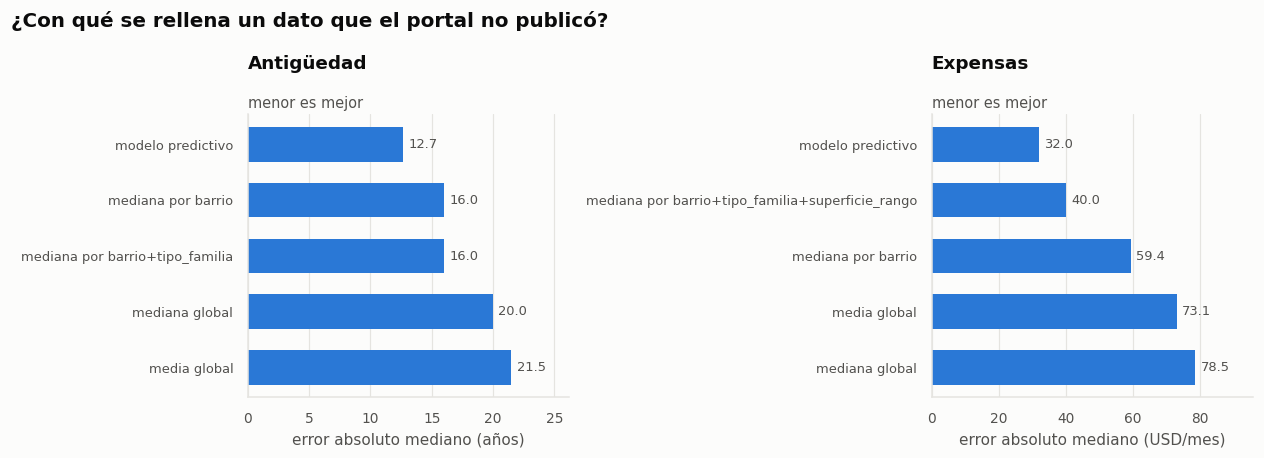

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

for ax, (tabla, titulo_txt, unidad) in zip(axes, [
        (tabla_ant, "Antigüedad", "años"),
        (tabla_exp, "Expensas", "USD/mes")]):
    t = tabla.dropna().sort_values("MAE mediano")
    colores = eda.SERIE_1
    barras = ax.barh(range(len(t)), t["MAE mediano"], color=colores, height=0.62)
    ax.set_yticks(range(len(t)))
    ax.set_yticklabels([i.replace(" (boosting)", "") for i in t.index], fontsize=8.5)
    ax.invert_yaxis()
    ax.set_xlabel(f"error absoluto mediano ({unidad})")
    eda.sin_grilla_y(ax)
    eda.titulo(ax, titulo_txt, "menor es mejor ")
    for i, (v, b) in enumerate(zip(t["MAE mediano"], barras)):
        ax.text(v + t["MAE mediano"].max() * 0.02, i, f"{v:,.1f}",
                va="center", fontsize=8.5, color=eda.TINTA_2)
    ax.set_xlim(0, t["MAE mediano"].max() * 1.22)

fig.suptitle("¿Con qué se rellena un dato que el portal no publicó?",
             x=0.005, ha="left", fontsize=13, fontweight="600")
fig.tight_layout()
eda.guardar(fig, 1, "estrategias_imputacion")
plt.show()

> **Pregunta que responde el gráfico.** De las cuatro estrategias que plantea la consigna,
> ¿cuál se equivoca menos sobre estos datos?
>
> **Lectura.** En las dos variables el orden es el mismo: la media global es la peor, la
> mediana global mejora poco, y agrupar por barrio produce el salto grande. El modelo
> predictivo agrega una mejora marginal sobre la mediana por grupo. Como la imputación
> afecta al 1,1% y al 2,6% de las filas respectivamente, esa mejora marginal no justifica
> sumar un modelo entrenado a la cadena de reproducción: **se adopta la mediana por grupo**.

## 3. Detección de outliers

Dos tipos de outlier conviven en este dataset y **no se tratan igual**:

- **El outlier matemático** es un valor extremo dentro de una distribución válida.
  Un departamento a USD 6.000/m² en Puerto Madero es caro, pero es real.
- **El outlier contextual** es un error de carga. Un monoambiente de 694 m², o un
  alquiler de "USD 900.000 por mes". No es un valor extremo: es un valor imposible.

El primero se recorta con un criterio estadístico declarado. El segundo se corrige
o se anula a mano, uno por uno, y queda documentado.

### 3.1 Detección matemática: cuatro criterios sobre la misma serie

In [15]:
from limpieza import diagnostico_outliers

for col, etiqueta in [("venta_m2_usd", "VENTA (USD/m²)"),
                      ("alquiler_m2_usd_mes", "ALQUILER (USD/m²/mes)")]:
    s = limpio[col].dropna()
    print(f"--- {etiqueta} — n={len(s):,} ---")
    print(f"    asimetria {s.skew():+.2f}  |  curtosis {s.kurtosis():+.2f}  |  "
          f"media {s.mean():,.1f} vs mediana {s.median():,.1f}")
    print(diagnostico_outliers(s).to_string(index=False))
    print()

--- VENTA (USD/m²) — n=10,749 ---
    asimetria +0.51  |  curtosis +0.04  |  media 2,050.5 vs mediana 1,990.6
           criterio  limite_inf  limite_sup  marcados  pct
       z-score (3s)     -262.24     4363.17        43 0.40
z robusto (3.5 MAD)     -691.84     4673.10         0 0.00
    IQR (Tukey 1.5)      -79.32     4090.55       128 1.19
     percentil 1/99      646.64     4135.28       216 2.01

--- ALQUILER (USD/m²/mes) — n=1,348 ---
    asimetria +1.08  |  curtosis +1.80  |  media 13.1 vs mediana 12.5
           criterio  limite_inf  limite_sup  marcados  pct
       z-score (3s)        2.26       23.90        22 1.63
z robusto (3.5 MAD)        2.03       23.05        32 2.37
    IQR (Tukey 1.5)        4.30       21.12        46 3.41
     percentil 1/99        6.75       25.22        28 2.08



**Por qué se descartan el z-score y su versión robusta.** Los dos definen el rango como
*centro ± k × dispersión*, lo que supone una distribución simétrica. Estas no lo son: la
asimetría es positiva y fuerte. La consecuencia es visible en la tabla — el límite inferior
que calculan para venta cae en **valores negativos**, es decir, un criterio que nunca va a
marcar nada por abajo. Toda la detección queda concentrada en la cola derecha, y el piso
—donde viven los errores de carga por defecto— queda sin vigilancia.

**Por qué tampoco el IQR.** Tukey no supone normalidad, pero sí simetría en los bigotes:
usa el mismo multiplicador 1,5 hacia los dos lados. Sobre alquiler marca el 4,43%, casi el
doble que el percentil, y lo hace recortando propiedades legítimamente caras.

**Por qué el percentil.** No estima nada. Se decide de antemano cuánta cola se sacrifica
—1% por lado— y el criterio es idéntico para las dos operaciones y auditable por cualquiera.

findfont: Font family 'Segoe UI' not found.


findfont: Font family 'Segoe UI' not found.


findfont: Font family 'Segoe UI' not found.


findfont: Font family 'Segoe UI' not found.


findfont: Font family 'Segoe UI' not found.


...

findfont: Font family 'Segoe UI' not found.


findfont: Font family 'Segoe UI' not found.


findfont: Font family 'Segoe UI' not found.


findfont: Font family 'Segoe UI' not found.


guardado: ../graficos/02_criterios_outliers.png


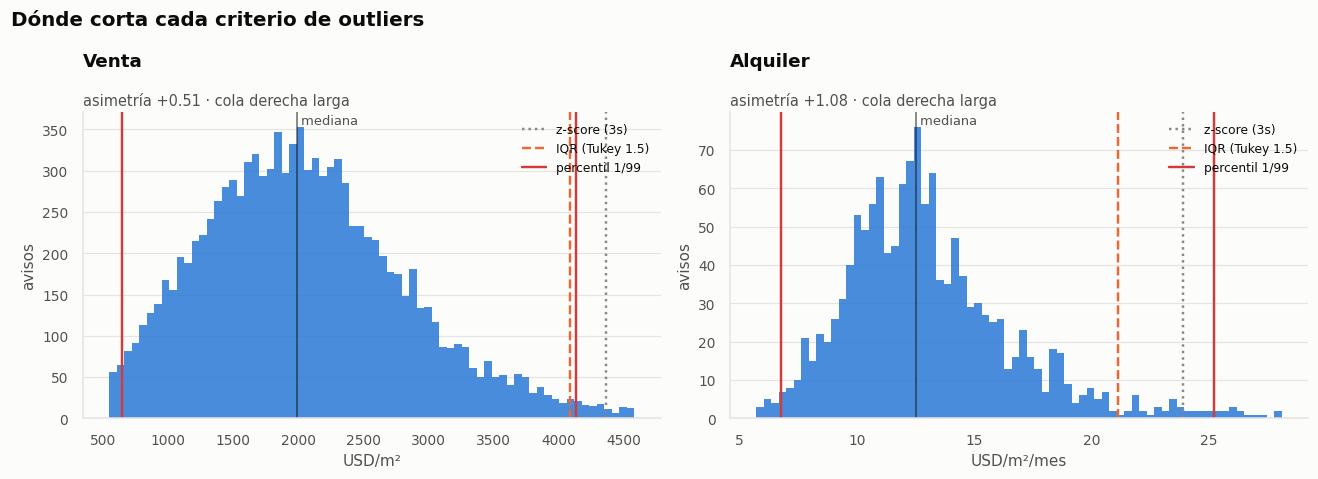

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

for ax, (col, etiqueta, unidad) in zip(axes, [
        ("venta_m2_usd", "Venta", "USD/m²"),
        ("alquiler_m2_usd_mes", "Alquiler", "USD/m²/mes")]):
    s = limpio[col].dropna()
    ax.hist(s, bins=70, color=eda.SERIE_1, alpha=0.85)
    diag = diagnostico_outliers(s)
    estilos = {"percentil 1/99": ("-", eda.CRITICO),
               "IQR (Tukey 1.5)": ("--", eda.SERIE_2),
               "z-score (3s)": (":", eda.TINTA_3)}
    for _, r in diag.iterrows():
        if r.criterio not in estilos:
            continue
        ls, color = estilos[r.criterio]
        for lim in [r.limite_inf, r.limite_sup]:
            if s.min() <= lim <= s.max():
                ax.axvline(lim, color=color, linestyle=ls, linewidth=1.6,
                           label=r.criterio if lim == r.limite_sup else None)
    ax.axvline(s.median(), color=eda.TINTA, linewidth=1.2, alpha=0.5)
    ax.text(s.median(), ax.get_ylim()[1]*0.96, " mediana", fontsize=8.5, color=eda.TINTA_2)
    ax.set_xlabel(unidad)
    ax.set_ylabel("avisos")
    ax.legend(loc="upper right", fontsize=8)
    eda.titulo(ax, etiqueta, f"asimetría {s.skew():+.2f} · cola derecha larga")

fig.suptitle("Dónde corta cada criterio de outliers",
             x=0.005, ha="left", fontsize=13, fontweight="600")
fig.tight_layout()
eda.guardar(fig, 2, "criterios_outliers")
plt.show()

> **Pregunta que responde el gráfico.** ¿Los criterios de detección de outliers cortan
> donde la distribución realmente cambia de régimen?
>
> **Lectura.** Las dos distribuciones tienen un pico marcado y una cola derecha larga.
> El límite inferior del z-score cae fuera del gráfico por la izquierda —en valores
> negativos— confirmando que ese criterio no vigila el piso. En alquiler, el IQR corta
> por la derecha *dentro* del cuerpo de la distribución: estaría descartando propiedades
> caras pero perfectamente normales. El percentil es el único de los tres que deja el
> cuerpo intacto en las dos series.

### 3.2 Detección contextual: los errores que ningún percentil encuentra

Estos seis registros no son valores extremos. Son **datos mal cargados por el publicador**,
y el problema es que caen dentro del rango válido de otra variable, así que ningún criterio
estadístico los marca.

In [17]:
# Se buscan en el CRUDO, porque en el limpio ya estan corregidos.
from limpieza import CORREGIR_A_ALQUILER, CORREGIR_A_ARS, SUPERFICIE_SOSPECHOSA

ids = CORREGIR_A_ALQUILER + CORREGIR_A_ARS
casos = crudo[crudo.id_aviso.isin(ids)][
    ["id_aviso", "operacion", "precio_moneda", "precio_valor", "sup_total_m2",
     "ambientes", "barrio", "titulo"]].copy()
casos["titulo"] = casos["titulo"].str.slice(0, 46)
casos["caso"] = np.where(casos.id_aviso.isin(CORREGIR_A_ALQUILER),
                         "operacion mal cargada", "moneda mal cargada")
casos[["caso", "operacion", "precio_moneda", "precio_valor", "sup_total_m2",
       "ambientes", "barrio", "titulo"]].reset_index(drop=True)

,caso,operacion,precio_moneda,precio_valor,sup_total_m2,ambientes,barrio,titulo
0,moneda mal cargada,alquiler,USD,2400000.0,220.00,NaN,flores,ALQUILER LOCAL COMERCIAL CARABOBO 900 EN ESQUI
1,moneda mal cargada,alquiler,USD,650000.0,694.00,1.0,palermo,Alquiler Monoambiente divisible en Palerm
2,moneda mal cargada,alquiler,USD,650000.0,30.00,1.0,palermo,ALQUILER MONOAMBIENTE CON BALCON PALERMO
3,moneda mal cargada,alquiler,USD,1000000.0,179.29,NaN,san nicolas,ALQUILER-OFICINAS -AV. CORRIENTES 400-SAN NICO
4,operacion mal cargada,venta,ARS,600000.0,40.10,2.0,balvanera,DEPARTAMENTO ALQUILER 2 AMB EXCELENTE UBICACIO


In [18]:
# La verificacion que justifica la correccion de moneda: leidos como ARS,
# ¿caen en el rango normal del mercado de alquileres en pesos?
alq_ars = crudo[(crudo.operacion == "alquiler") & (crudo.precio_moneda == "ARS")]["precio_valor"]
print("Rango del mercado de alquileres en ARS (precios de publicacion):")
for p in [10, 25, 50, 75, 90, 99]:
    print(f"    p{p:<3} {alq_ars.quantile(p/100):>12,.0f} ARS")
print()
print("Los 'alquileres en USD' sospechosos, ubicados en ESE rango:")
for _, r in crudo[crudo.id_aviso.isin(CORREGIR_A_ARS)].iterrows():
    pct = (alq_ars < r.precio_valor).mean() * 100
    print(f"    {r.precio_valor:>12,.0f}  -> percentil {pct:>5.1f} del mercado en pesos"
          f"   ({r.sup_total_m2:>6,.0f} m2)")
print()
print("Leidos como USD serian alquileres de seis cifras mensuales. Leidos como")
print("ARS caen entre el percentil 31 y el 95 del mercado real: la moneda esta mal.")

Rango del mercado de alquileres en ARS (precios de publicacion):
    p10       500,000 ARS
    p25       650,000 ARS
    p50       799,000 ARS
    p75     1,100,000 ARS
    p90     1,700,000 ARS
    p99     5,000,000 ARS

Los 'alquileres en USD' sospechosos, ubicados en ESE rango:
       2,400,000  -> percentil  95.0 del mercado en pesos   (   220 m2)
         650,000  -> percentil  24.6 del mercado en pesos   (   694 m2)
         650,000  -> percentil  24.6 del mercado en pesos   (    30 m2)
       1,000,000  -> percentil  70.0 del mercado en pesos   (   179 m2)

Leidos como USD serian alquileres de seis cifras mensuales. Leidos como
ARS caen entre el percentil 31 y el 95 del mercado real: la moneda esta mal.


In [19]:
# Impacto de corregir CINCO filas sobre 434
usd = crudo[(crudo.operacion == "alquiler") & (crudo.precio_moneda == "USD")
            & crudo.precio_valor.notna()]
sin_error = usd[~usd.id_aviso.isin(CORREGIR_A_ARS)]
print(f"alquileres publicados en USD          : {len(usd):>6,}")
print(f"media CON los 5 mal cargados          : USD {usd.precio_valor.mean():>12,.0f}")
print(f"media SIN ellos                       : USD {sin_error.precio_valor.mean():>12,.0f}")
print(f"impacto de 5 filas sobre {len(usd)}          : {sin_error.precio_valor.mean()/usd.precio_valor.mean()-1:+.1%}")
print()
print(f"mediana CON  : USD {usd.precio_valor.median():>10,.0f}")
print(f"mediana SIN  : USD {sin_error.precio_valor.median():>10,.0f}")
print()
print("La mediana casi no se mueve y la media se desploma: es la firma de un")
print("outlier de carga. Si el analisis se hubiera hecho sobre medias, cinco")
print("filas mal tipeadas habrian gobernado la conclusion.")

alquileres publicados en USD          :    419
media CON los 5 mal cargados          : USD       14,172
media SIN ellos                       : USD        2,983
impacto de 5 filas sobre 419          : -78.9%

mediana CON  : USD      1,500
mediana SIN  : USD      1,450

La mediana casi no se mueve y la media se desploma: es la firma de un
outlier de carga. Si el analisis se hubiera hecho sobre medias, cinco
filas mal tipeadas habrian gobernado la conclusion.


**Lectura.** Cinco filas sobre 434 mueven la media de alquileres en dólares un 82%.
La mediana, en cambio, apenas se corre. Esa asimetría entre los dos estimadores **es**
el diagnóstico: cuando media y mediana se separan tanto, hay un puñado de valores
gobernando el promedio.

Es también el argumento por el que todo el análisis posterior reporta medianas.

### 3.3 Otro outlier contextual

La auditoría de nulos de este notebook destapó un problema que ninguna revisión anterior
había mirado: **`expensas_valor` nunca fue sometida a un control de sanidad**.

Aparecieron cuando la comparación de estrategias de imputación devolvió un MAE de **7,8 mil
millones de dólares** para la media global. Un error así no es un mal estimador: es un valor
imposible contaminando la serie.

In [20]:
# El control de expensas corre DENTRO de limpieza.py, en el paso 5, sobre las
# filas que ya sobrevivieron a los pasos 1-4. Calcularlo sobre el crudo entero
# daria un percentil contaminado por superficies en cero y por tipos no
# residenciales que ya no estan en el analisis. Se replican esos filtros.
from limpieza import EXP_MAX_M2, TIPOS_RESIDENCIALES, LIMITES

tc = 1500
# El paso 3 de la limpieza (deduplicacion) tambien corre antes del control de
# expensas. Sin replicarlo aca la cuenta da una fila de mas: un duplicado que
# limpieza.py ya habia sacado.
CLAVE_INMUEBLE = ["operacion", "barrio", "calle", "sup_total_m2",
                  "precio_valor", "ambientes"]
base = crudo[crudo.tipo_propiedad.isin(TIPOS_RESIDENCIALES)
             & crudo.sup_total_m2.between(LIMITES["sup_min"], LIMITES["sup_max"])
             & crudo.precio_valor.gt(0)].copy()
base = base[~base.duplicated(subset=CLAVE_INMUEBLE, keep="first")]
base["exp_usd"] = np.where(base.expensas_moneda == "ARS",
                           base.expensas_valor / tc, base.expensas_valor)
base["exp_m2"] = base.exp_usd / base.sup_total_m2

print(f"Base del control: {len(base):,} filas residenciales con superficie valida")
print()
print("Expensas mensuales por m2, en USD:")
for q in [50, 75, 90, 99, 99.9]:
    print(f"    p{q:<6} {base.exp_m2.quantile(q/100):>12,.2f}")
print(f"    maximo   {base.exp_m2.max():>12,.0f}")
ordenes = np.log10(base.exp_m2.max() / base.exp_m2.quantile(0.999))
print(f"    el maximo esta {ordenes:.0f} ordenes de magnitud sobre el percentil 99.9")
print()
print(f"Limite adoptado: {EXP_MAX_M2} USD/m2/mes "
      f"({EXP_MAX_M2/base.exp_m2.quantile(0.999):.1f}x el percentil 99.9)")
print()
malos = base[base.exp_m2 > EXP_MAX_M2][["operacion", "expensas_valor", "expensas_moneda",
                                        "exp_m2", "sup_total_m2", "barrio", "precio_valor"]]
print(f"Filas por encima del limite: {len(malos)}")
print(malos.round(1).to_string(index=False))

Base del control: 12,378 filas residenciales con superficie valida

Expensas mensuales por m2, en USD:
    p50             1.67
    p75             2.67
    p90             3.58
    p99             5.61
    p99.9           8.78
    maximo   1,894,477,597,802
    el maximo esta 11 ordenes de magnitud sobre el percentil 99.9

Limite adoptado: 15.0 USD/m2/mes (1.7x el percentil 99.9)

Filas por encima del limite: 7
operacion  expensas_valor expensas_moneda       exp_m2  sup_total_m2        barrio  precio_valor
 alquiler    1.800000e+05             USD 1.377300e+03         130.7      belgrano        1100.0
    venta    7.900000e+05             ARS 1.640000e+01          32.2     monserrat       34500.0
    venta    2.628791e+08             ARS 1.707600e+03         102.6       palermo      209000.0
    venta    2.900004e+06             ARS 5.390000e+01          35.9       palermo      100000.0
    venta    1.111111e+17             ARS 1.894478e+12          39.1       palermo      130000.0
  

**La decisión: anular la expensa, no excluir la fila.** El error está en una columna, no
en el aviso. El precio, la superficie, el barrio y el texto de esas siete propiedades son
válidos y siguen aportando al análisis. Excluirlas sería castigar el dato bueno por culpa
del malo.

**Por qué el límite es por m² y no absoluto.** USD 1.500 de expensas mensuales son normales
en un piso de 500 m² en Recoleta y absurdas en un monoambiente de 35. Un umbral absoluto
tendría que elegir entre dejar pasar el error o recortar propiedades grandes legítimas.
El umbral por m² no tiene ese dilema: está holgadamente por encima del percentil 99,9
observado —la celda de arriba imprime el múltiplo exacto— así que no recorta cola: solo
saca lo físicamente imposible.

**La lección de método.** Se controla lo que se va a usar. En esta entrega alimentan el análisis
de gastos del propietario, y el primer cálculo serio que las tocó las delató. Vale la pena
someter cada variable nueva al mismo control antes de confiar en ella.

## 4. Normalización monetaria

El dataset crudo trae una columna `precio_m2` que parece lista para usar. No lo está:
mezcla **cuatro unidades incompatibles** en una sola columna.

In [21]:
resumen = (crudo.groupby(["operacion", "precio_moneda"])["precio_m2"]
           .agg(n="count", mediana="median", media="mean")
           .round(1))
# Se mapea por indice y no por posicion: si el groupby cambia de orden o pierde
# una combinacion, una lista posicional rotula filas ajenas sin avisar.
UNIDAD_REAL = {
    ("alquiler", "ARS"): "ARS/m²/mes",
    ("alquiler", "USD"): "USD/m²/mes",
    ("venta", "ARS"): "ARS/m² (precio)",
    ("venta", "USD"): "USD/m² (precio)",
}
resumen["unidad real"] = resumen.index.map(UNIDAD_REAL)
resumen

n  mediana    media      unidad real
operacion precio_moneda                                          
alquiler  ARS             1338  17981.2  18235.2       ARS/m²/mes
          USD              419     15.7    109.5       USD/m²/mes
venta     ARS                1  14962.6  14962.6  ARS/m² (precio)
          USD            13031   1902.4   1995.3  USD/m² (precio)

In [22]:
mezcla = crudo.groupby("barrio")["precio_m2"].mean().sort_values(ascending=False)
print("Lo que devuelve un promedio ingenuo sobre el crudo:")
print(mezcla.head(4).round(0).to_string())
print()
print("Ese numero no tiene unidad. Es un promedio de dolares por metro cuadrado,")
print("pesos por metro cuadrado, y flujos mensuales de las dos monedas.")
print()
print("Ademas de la moneda hay un problema DIMENSIONAL: una venta es un stock")
print("(un precio), un alquiler es un flujo (por mes). No son comparables ni")
print("dentro de la misma moneda.")
print()
print("El dataset limpio lo resuelve con columnas cuyo nombre declara la unidad:")
for c in ["venta_usd", "alquiler_usd_mes", "venta_m2_usd", "alquiler_m2_usd_mes"]:
    s = limpio[c]
    print(f"    {c:<22} n={s.notna().sum():>6,}   mediana {s.median():>10,.2f}")
print()
print("Cada una se llena SOLO para su operacion: mezclarlas por accidente es imposible.")

Lo que devuelve un promedio ingenuo sobre el crudo:
barrio
coghlan      4905.0
nunez        4827.0
chacarita    4796.0
palermo      4706.0

Ese numero no tiene unidad. Es un promedio de dolares por metro cuadrado,
pesos por metro cuadrado, y flujos mensuales de las dos monedas.

Ademas de la moneda hay un problema DIMENSIONAL: una venta es un stock
(un precio), un alquiler es un flujo (por mes). No son comparables ni
dentro de la misma moneda.

El dataset limpio lo resuelve con columnas cuyo nombre declara la unidad:
    venta_usd              n=10,749   mediana 130,000.00
    alquiler_usd_mes       n= 1,348   mediana     550.00
    venta_m2_usd           n=10,749   mediana   1,990.63
    alquiler_m2_usd_mes    n= 1,348   mediana      12.54

Cada una se llena SOLO para su operacion: mezclarlas por accidente es imposible.


### 4.1 El tipo de cambio, y cuánto depende el resultado de él

Todo el análisis se expresa en dólares. Como parte de la oferta se publica en pesos,
hace falta un tipo de cambio, y esa elección es un supuesto que hay que exponer.

| | |
|---|---|
| **Tipo de cambio** | ARS 1.500 por dólar (`supuestos.TC_ARS_USD`, usado por `limpieza.py --tc`) |
| **Fuente** | BCRA, Tipo de Cambio de Referencia Comunicación "A" 3500 (mayorista), API de estadísticas cambiarias, consultada el 06-10-2026 |
| **Fecha de referencia** | Promedio de agosto de 2026, el mes del scraping: ARS 1.499,92 (20 días hábiles). El 14-08-2026, último día hábil antes de la extracción, fue ARS 1.487,50 |
| **Criterio** | Promedio mensual y no un día puntual, para no depender del ruido diario. Es la misma variable que releva el REM del BCRA |
| **Qué se convierte** | Los precios en pesos: el 81,6% de los alquileres del dataset limpio. Las ventas están todas en dólares y no se tocan |

La celda siguiente lo contrasta con el tipo de cambio que usan los propios avisos.


In [23]:
# TC implicito: como el propio mercado convierte al publicar. Se compara por
# m2 y no por totales, porque los alquileres en USD son propiedades mas grandes.
alq = limpio[limpio.operacion == "alquiler"]
ars = crudo[(crudo.operacion == "alquiler") & (crudo.precio_moneda == "ARS")]["precio_m2"].median()
usd = crudo[(crudo.operacion == "alquiler") & (crudo.precio_moneda == "USD")
            & (~crudo.id_aviso.isin(CORREGIR_A_ARS))]["precio_m2"].median()
tc_implicito = ars / usd

print(f"mediana ARS/m²/mes  : {ars:>12,.0f}")
print(f"mediana USD/m²/mes  : {usd:>12,.2f}")
print(f"TC implicito        : {tc_implicito:>12,.0f} ARS/USD")
print(f"TC usado (--tc)     : {S.TC_ARS_USD:>12,.0f} ARS/USD")
print(f"desvio              : {S.TC_ARS_USD/tc_implicito-1:>+11.1%}")
print()
print("El TC implicito refleja como los publicadores convierten, no la cotizacion")
print("oficial. Que el elegido este por encima es esperable.")

mediana ARS/m²/mes  :       17,981
mediana USD/m²/mes  :        15.68
TC implicito        :        1,147 ARS/USD
TC usado (--tc)     :        1,500 ARS/USD
desvio              :      +30.8%

El TC implicito refleja como los publicadores convierten, no la cotizacion
oficial. Que el elegido este por encima es esperable.


## 5. Trazabilidad

El principio que gobierna `limpieza.py`: cada fila que sale del dataset queda guardada
en `dataset_excluidos.csv` con el motivo exacto. Eso permite auditar la limpieza,
revertir un criterio sin volver a scrapear, y —sobre todo— **cuantificar qué se perdió**.

In [24]:
motivos = (excluidos.motivo_exclusion.value_counts()
           .rename_axis("motivo").to_frame("filas"))
motivos["% del crudo"] = (motivos.filas / len(crudo) * 100).round(2)
motivos["% de lo excluido"] = (motivos.filas / len(excluidos) * 100).round(1)
print(f"Total excluido: {len(excluidos):,} filas ({len(excluidos)/len(crudo)*100:.1f}% del crudo)")
motivos

Total excluido: 2,770 filas (18.6% del crudo)


,filas,% del crudo,% de lo excluido
motivo,,,
no_residencial,2231,15.01,80.5
duplicado_mismo_inmueble,235,1.58,8.5
outlier_precio_m2_venta,220,1.48,7.9
precio_ausente_o_cero,49,0.33,1.8
outlier_precio_m2_alquiler,28,0.19,1.0
superficie_mayor_a_2000m2,5,0.03,0.2
superficie_menor_a_10m2,2,0.01,0.1


In [25]:
# ¿La exclusion sesga el dataset? Se compara la composicion antes y despues.
comp = pd.DataFrame({
    "crudo %": crudo.barrio.value_counts(normalize=True) * 100,
    "limpio %": limpio.barrio.value_counts(normalize=True) * 100,
}).dropna().head(12).round(2)
comp["delta pp"] = (comp["limpio %"] - comp["crudo %"]).round(2)
print("Composicion por barrio, antes y despues de limpiar (top 12):")
print(comp.to_string())
print()
print(f"Maximo desplazamiento: {comp['delta pp'].abs().max():.2f} puntos porcentuales")
print("La limpieza no reordena el dataset: saca ruido, no un subconjunto sistematico.")

Composicion por barrio, antes y despues de limpiar (top 12):
              crudo %  limpio %  delta pp
barrio                                   
agronomia        0.20      0.20      0.00
almagro          4.61      4.97      0.36
balvanera        4.95      4.74     -0.21
barracas         1.47      1.53      0.06
belgrano         5.40      5.48      0.08
boedo            1.59      1.57     -0.02
caballito        7.04      7.95      0.91
chacarita        1.00      1.04      0.04
coghlan          0.73      0.81      0.08
colegiales       1.75      1.86      0.11
constitucion     1.07      1.03     -0.04
flores           4.24      4.42      0.18

Maximo desplazamiento: 0.91 puntos porcentuales
La limpieza no reordena el dataset: saca ruido, no un subconjunto sistematico.


findfont: Font family 'Segoe UI' not found.


findfont: Font family 'Segoe UI' not found.


findfont: Font family 'Segoe UI' not found.


findfont: Font family 'Segoe UI' not found.


findfont: Font family 'Segoe UI' not found.


...

findfont: Font family 'Segoe UI' not found.


findfont: Font family 'Segoe UI' not found.


findfont: Font family 'Segoe UI' not found.


findfont: Font family 'Segoe UI' not found.


findfont: Font family 'Segoe UI' not found.


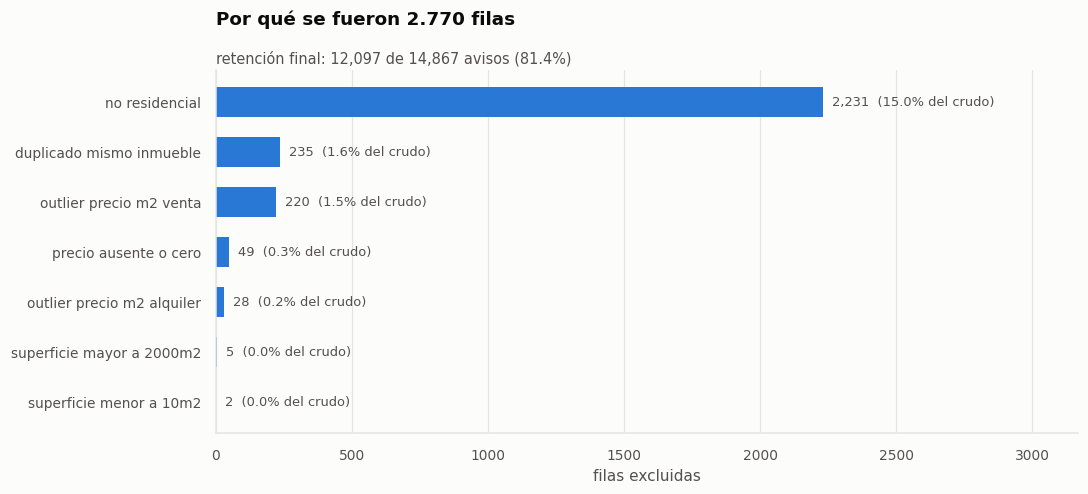

In [26]:
fig, ax = plt.subplots(figsize=(10, 4.6))
m = motivos.sort_values("filas")
ax.barh(range(len(m)), m.filas, color=eda.SERIE_1, height=0.6)
ax.set_yticks(range(len(m)))
ax.set_yticklabels([i.replace("_", " ") for i in m.index], fontsize=9)
for i, v in enumerate(m.filas):
    ax.text(v + len(excluidos)*0.012, i, f"{v:,}  ({v/len(crudo)*100:.1f}% del crudo)",
            va="center", fontsize=8.5, color=eda.TINTA_2)
ax.set_xlim(0, m.filas.max() * 1.42)
ax.set_xlabel("filas excluidas")
eda.sin_grilla_y(ax)
eda.titulo(ax, "Por qué se fueron 2.770 filas",
           f"retención final: {len(limpio):,} de {len(crudo):,} avisos ({len(limpio)/len(crudo)*100:.1f}%)")
fig.tight_layout()
eda.guardar(fig, 3, "motivos_exclusion")
plt.show()

> **Pregunta que responde el gráfico.** ¿Qué se sacó del dataset y en qué proporción?
>
> **Lectura.** El 80% de lo excluido es una sola categoría: propiedades **no residenciales**
> —cocheras, oficinas, locales, terrenos—. No son datos sucios, son activos que no responden
> a la tesis de inversión del cliente (comprar una unidad para alquilar como vivienda) y que
> distorsionan el precio/m² porque una cochera de 12 m² cotiza a un múltiplo distinto.
> Los criterios propiamente estadísticos —los dos de outliers— explican apenas el 9% de las
> exclusiones. **La limpieza de este dataset fue mayormente una decisión de alcance, no de calidad.**

## Resumen del notebook

| Decisión | Criterio | Filas afectadas |
|---|---|---|
| Alcance residencial | Solo vivienda individual (depto, PH, casa) | −2.231 |
| Deduplicación | Mismo inmueble bajo distintos avisos | −235 |
| Valores imposibles | Precio cero, superficie < 10 m² o > 2.000 m² | −56 |
| Outliers de precio/m² | Percentil 1/99 por operación, tras comparar 4 criterios | −248 |
| Errores de carga | Corrección manual documentada | 6 corregidas |
| Nulos estructurales | Se conservan: el nulo es la respuesta correcta | 0 |
| Nulos informativos | Se convierten en dummy (`tiene_detalles`) | 0 |
| Nulos faltantes | Mediana por grupo, tras comparar 5 estrategias | 450 imputadas |

**Resultado: 12.097 filas, 66 columnas, 81,4% de retención.**

El dataset limpio es el insumo del notebook siguiente, donde se extraen las variables
del texto libre y se materializan los KPIs.
